# Step 4: Explainability via SHAP - Retail Cohort (14 features, k=4)

SHAP (SHapley Additive exPlanations) is applied via a surrogate Random Forest model with 200 trees, trained on the K-Means++ k=4 cluster labels from the retail cohort (n=3,741).

## Methodology

Since K-Means is **unsupervised**, SHAP requires a surrogate model:

1. Train a **RandomForestClassifier (200 trees)** to predict the k=4 cluster labels of the retail cohort
2. Apply **SHAP TreeExplainer** to analyze feature contributions at the individual customer level
3. Aggregate SHAP values to build feature importance rankings by cluster

**Prerequisites:** Run `02_feature_engineering.ipynb` and `03_modeling.ipynb` first.

**Inputs:**
* `data/processed/customer_features_retail_scaled.csv`: 3,741 x 14 normalized features
* `data/processed/cluster_assignments_retail_k4.csv`: k=4 cluster labels

## Set up

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import shap
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

ROOT = Path("../").resolve()
sys.path.insert(0, str(ROOT / "src"))

from notebook_io import rpath

RETAIL_SCALED_PATH = rpath("processed/customer_features_retail_scaled.csv")
CLUSTERS_PATH      = rpath("processed/cluster_assignments_retail_k4.csv")
FIG_DIR = ROOT / "figures" / "04_shap"
FIG_DIR.mkdir(parents=True, exist_ok=True)

CLUSTER_NAMES  = {
    0: 'C0 Seasonal Intensives',
    1: 'C1 High-Return Actives',
    2: 'C2 One-Time Explorers',
    3: 'C3 Occasional Loyalists',
}
# Wong CVD-safe palette: C0=orange, C1=blue, C2=bluish-green, C3=reddish-purple
from visual_style import CLUSTER_COLORS

c:\Users\Hung Thinh PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Data

In [2]:
df_retail = pd.read_csv(RETAIL_SCALED_PATH, index_col='CustomerID')
X_retail   = df_retail.values
feat_cols  = df_retail.columns.tolist()

clusters    = pd.read_csv(CLUSTERS_PATH).set_index('CustomerID')
labels      = clusters.reindex(df_retail.index)['cluster'].values.astype(int)

print(f"Retail cohort : {df_retail.shape[0]:,} customers × {df_retail.shape[1]} features")

Retail cohort : 3,741 customers × 14 features


# 2. Surrogate Model

A 200-tree RandomForestClassifier was trained **in-sample** on the full 3,741 retail customers. An in-sample accuracy of 1.000 merely confirms that the RF can faithfully reconstruct the K-Means labels on the training data. Cross-validation and seed sensitivity are reported separately.

SHAP TreeExplainer then decomposes each customer's prediction into individual feature contributions.

In [3]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_retail, labels)
acc = rf.score(X_retail, labels)
print(f"Surrogate RF in-sample accuracy: {acc:.4f}")

explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_retail)

# Normalise SHAP output: newer SHAP returns 3D (n_samples, n_features, n_classes);
# older API returns list of (n_samples, n_features). Standardise to list of 2D arrays.
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values = [shap_values[:, :, c] for c in range(shap_values.shape[2])]

print(f"SHAP computed: {len(shap_values)} classes × {shap_values[0].shape}")

Surrogate RF in-sample accuracy: 1.0000
SHAP computed: 4 classes × (3741, 14)


In [4]:
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score

majority_baseline = pd.Series(labels).value_counts(normalize=True).max()
print(f"Majority-class baseline accuracy : {majority_baseline:.4f}  (C2 One-Time Explorers, n=1,257)")

print("\nIn-sample classification report (all 3,741 customers):")
print(classification_report(labels, rf.predict(X_retail),
                             target_names=list(CLUSTER_NAMES.values())))

cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_retail, labels, cv=cv_folds, scoring='accuracy')
print(f"Stratified 5-fold CV accuracy : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Fold scores                   : {[f'{s:.4f}' for s in cv_scores]}")

Majority-class baseline accuracy : 0.3360  (C2 One-Time Explorers, n=1,257)

In-sample classification report (all 3,741 customers):
                         precision    recall  f1-score   support

 C0 Seasonal Intensives       1.00      1.00      1.00       330
 C1 High-Return Actives       1.00      1.00      1.00      1107
  C2 One-Time Explorers       1.00      1.00      1.00      1257
C3 Occasional Loyalists       1.00      1.00      1.00      1047

               accuracy                           1.00      3741
              macro avg       1.00      1.00      1.00      3741
           weighted avg       1.00      1.00      1.00      3741



Stratified 5-fold CV accuracy : 0.9904 ± 0.0023
Fold scores                   : ['0.9880', '0.9893', '0.9893', '0.9906', '0.9947']


# 3. Global Feature Importance

Total |SHAP| aggregated across all customers and 4 classes, normalized to sum to 1. This represents the relative attribution magnitude of the surrogate model, not causal importance.

In [5]:
global_abs = np.sum([np.abs(sv) for sv in shap_values], axis=0)  # (n_customers, n_features)
mean_abs   = global_abs.mean(axis=0)                              # (n_features,)
mean_abs_norm = mean_abs / mean_abs.sum()

feat_importance = pd.Series(mean_abs_norm, index=feat_cols).sort_values(ascending=False)
print("Global feature importance (total |SHAP|, normalised):")
for i, (feat, val) in enumerate(feat_importance.items()):
    print(f"  {i+1:2d}. {feat:<28} {val:.4f}")

print(f"\nTop 5 features account for {feat_importance.head(5).sum():.1%} of discriminating power.")

Global feature importance (total |SHAP|, normalised):
   1. ReturnRate                   0.2745
   2. QuarterConcentration         0.2098
   3. BasketSizeCV                 0.1840
   4. RepeatSKUFraction            0.1123
   5. MonthlyOrderRate             0.0998
   6. InterPurchaseCV              0.0571
   7. Recency                      0.0115
   8. AOV                          0.0111
   9. SKU_HHI                      0.0109
  10. SpendAcceleration            0.0086
  11. BulkLineRate                 0.0068
  12. MedianBasketQty              0.0049
  13. QuantityCV                   0.0046
  14. PriceCV                      0.0040

Top 5 features account for 88.0% of discriminating power.


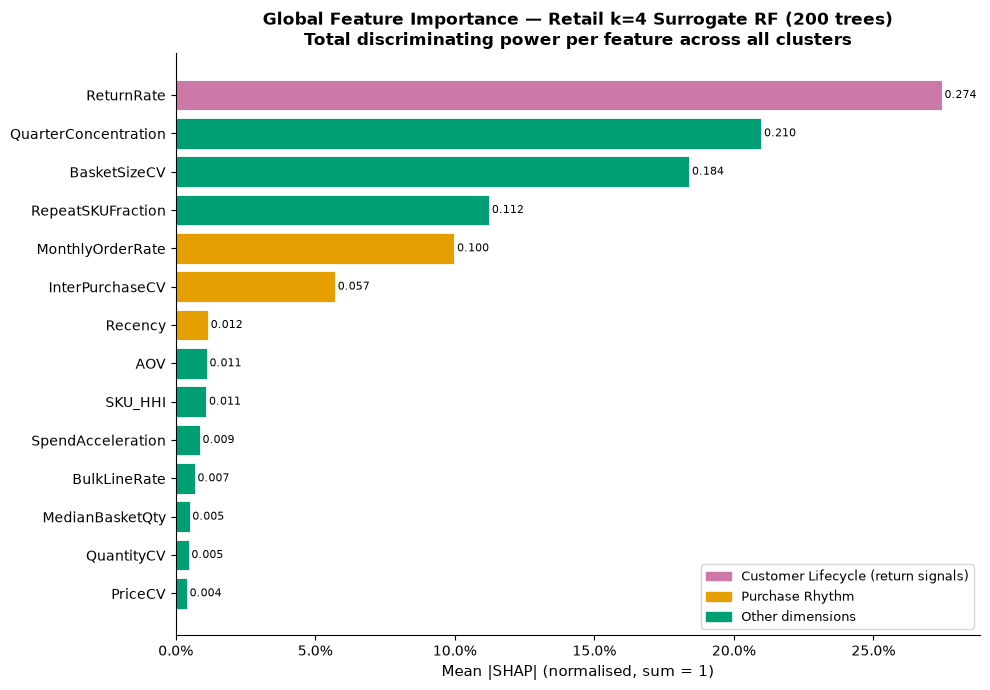

Saved: C:\Users\Hung Thinh PC\OneDrive\Documents\AIO 2026\Project2.2\customer_segmentation_ai_vietnam\figures\04_shap\shap_importance_retail_k4.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 7))

order = feat_importance.index.tolist()[::-1]
vals  = feat_importance[order].values
# Wong-compatible feature category colors
colors = ['#CC79A7' if f in ('ReturnRate', 'ReturnValueRate') else
          '#E69F00' if f in ('ActiveSpanDays', 'MonthlyOrderRate', 'Recency', 'InterPurchaseCV') else
          '#009E73' for f in order]

bars = ax.barh(order, vals, color=colors, edgecolor='white', linewidth=0.6)
ax.set_xlabel('Mean |SHAP| (normalised, sum = 1)', fontsize=11)
ax.set_title('Global Feature Importance — Retail k=4 Surrogate RF (200 trees)\n'
             'Total discriminating power per feature across all clusters', fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))

for bar, val in zip(bars, vals):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#CC79A7', label='Customer Lifecycle (return signals)'),
    Patch(color='#E69F00', label='Purchase Rhythm'),
    Patch(color='#009E73', label='Other dimensions'),
], fontsize=9, loc='lower right')

ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_importance_retail_k4.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', FIG_DIR / 'shap_importance_retail_k4.png')

## 4. SHAP Direction Matrix - Mean Signed SHAP by Cluster

For each cluster, the mean signed SHAP value per feature indicates the **direction** in which each feature pushes a customer into (positive) or away from (negative) that cluster.

2x2 grid – one subplot for each cluster.

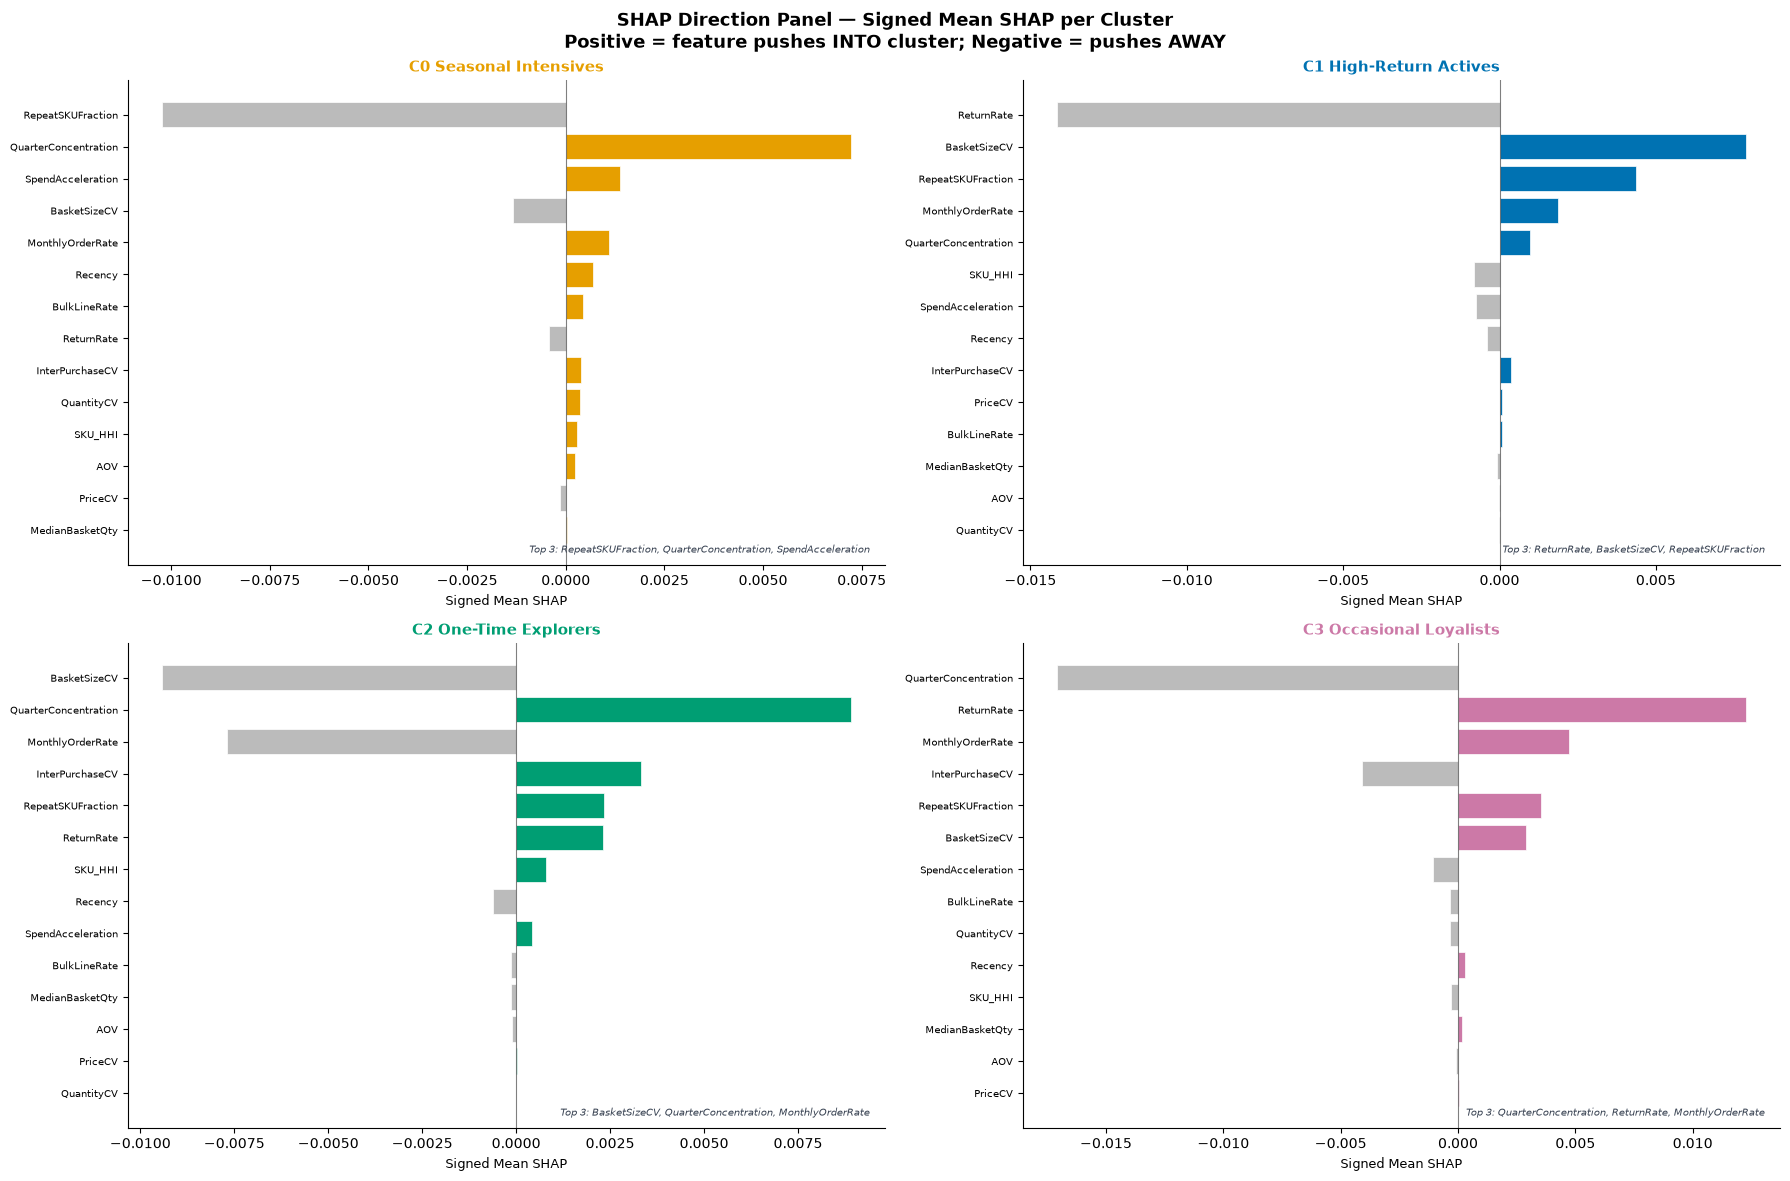

Saved: C:\Users\Hung Thinh PC\OneDrive\Documents\AIO 2026\Project2.2\customer_segmentation_ai_vietnam\figures\04_shap\shap_direction_retail_k4.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('SHAP Direction Panel — Signed Mean SHAP per Cluster\n'
             'Positive = feature pushes INTO cluster; Negative = pushes AWAY',
             fontsize=13, fontweight='bold')

for ax, c in zip(axes.flat, range(4)):
    sv          = shap_values[c]                      # (n, 18)
    mean_signed = sv.mean(axis=0)                     # (18,)
    order       = np.argsort(np.abs(mean_signed))
    feats_ord   = [feat_cols[i] for i in order]
    vals_ord    = mean_signed[order]
    # Wong-compatible directional colors: cluster color for positive, muted for negative
    bar_colors  = [CLUSTER_COLORS[c] if v > 0 else '#BBBBBB' for v in vals_ord]

    ax.barh(feats_ord, vals_ord, color=bar_colors, edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='black', lw=0.8, alpha=0.5)
    ax.set_title(CLUSTER_NAMES[c], fontsize=11, fontweight='bold', color=CLUSTER_COLORS[c])
    ax.set_xlabel('Signed Mean SHAP', fontsize=9)
    ax.tick_params(axis='y', labelsize=7.5)
    ax.spines[['top', 'right']].set_visible(False)

    top3 = pd.Series(mean_signed, index=feat_cols).abs().nlargest(3).index.tolist()
    ax.text(0.98, 0.02, 'Top 3: ' + ', '.join(top3),
            transform=ax.transAxes, ha='right', va='bottom', fontsize=7.5,
            style='italic', color='#374151')

plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_direction_retail_k4.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', FIG_DIR / 'shap_direction_retail_k4.png')

## 5. SHAP Beeswarm Plot - Per-Customer Distribution

How to read:

* **Y-axis:** Features ranked by mean |SHAP| for that cluster (most important at top)
* **X-axis:** SHAP value; positive pushes into cluster, negative pushes away from cluster
* **Color:** Feature value, red = high (z-score), blue = low (z-score)
* **Each dot:** One customer

A red dot on the positive side means "a high feature value pushes this customer into that cluster".

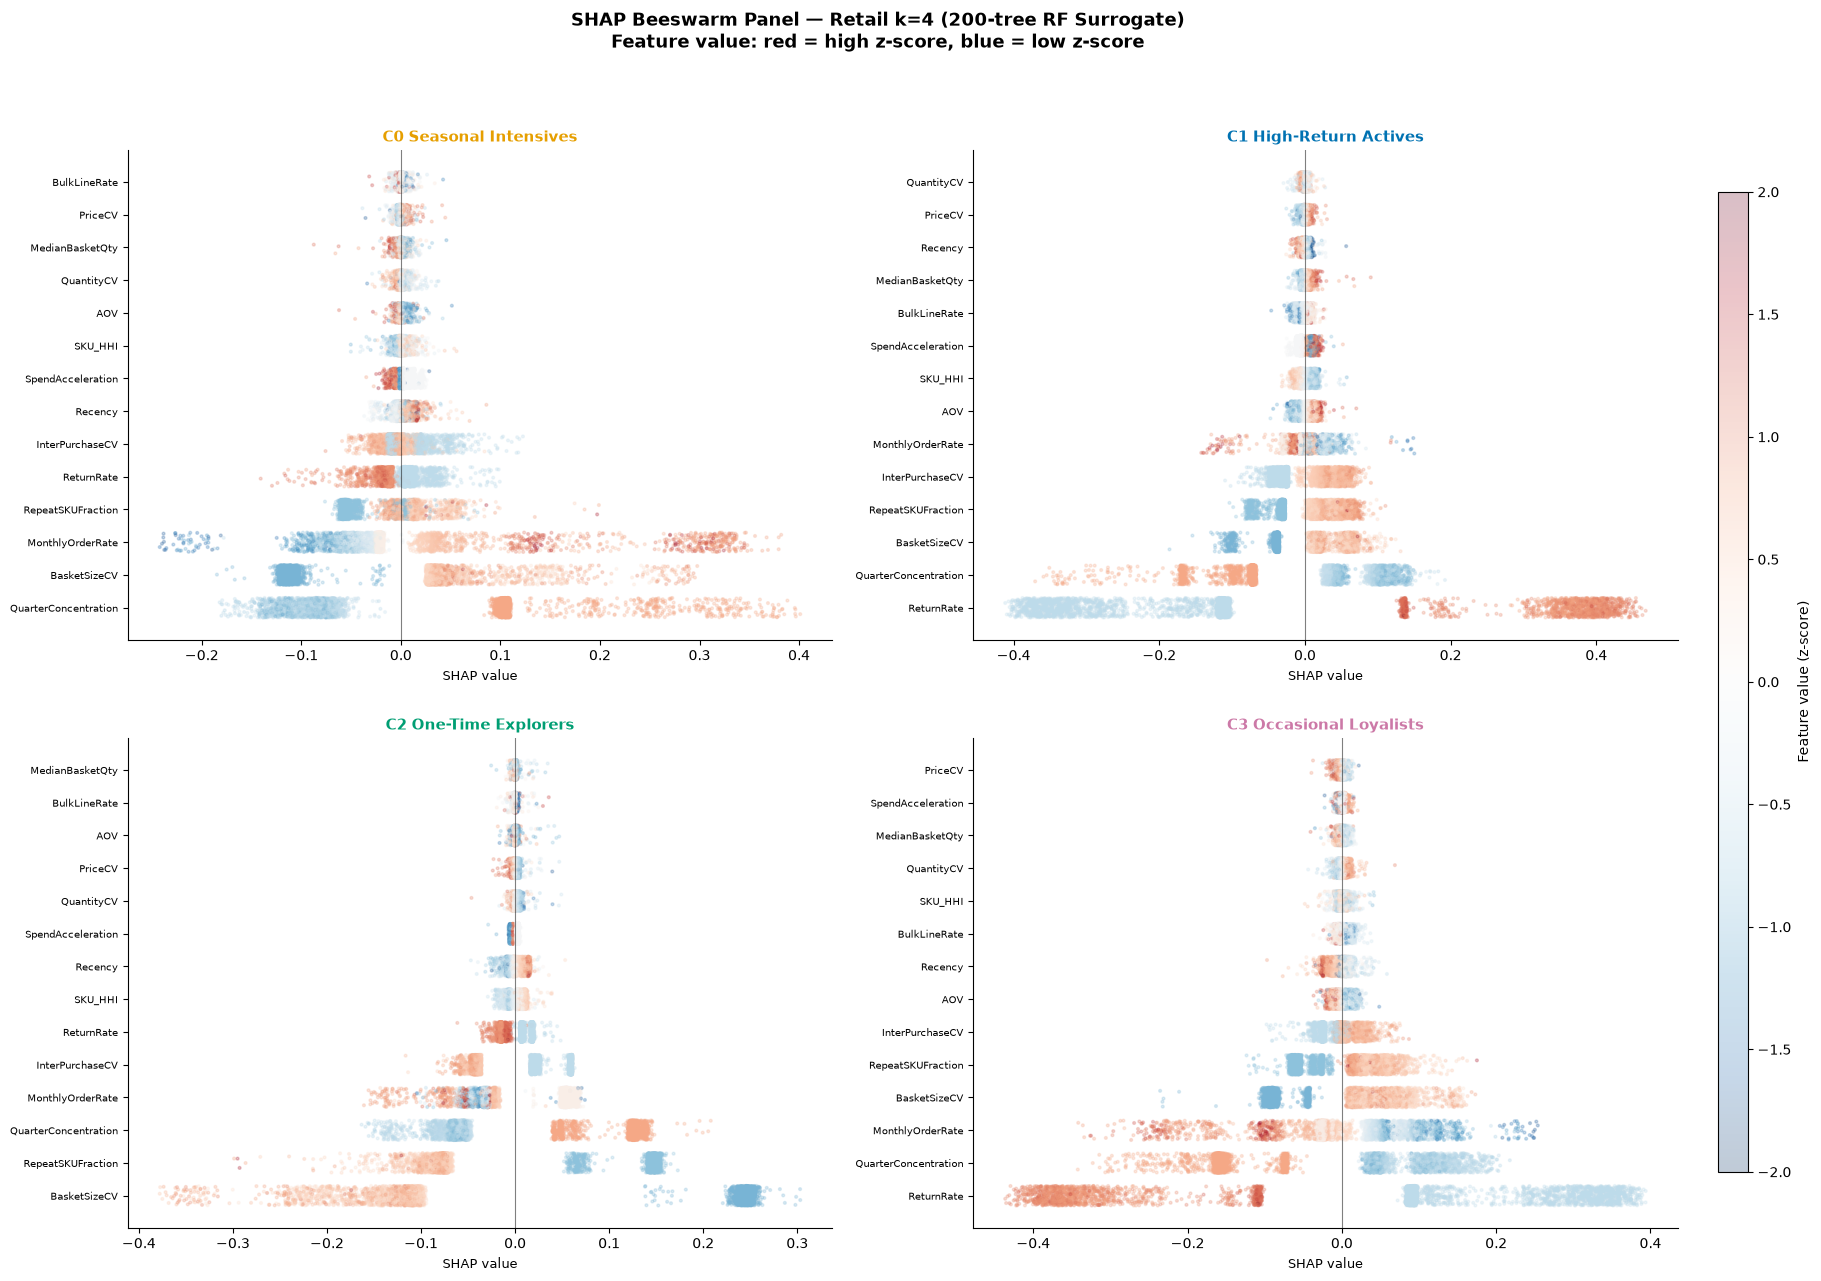

Saved: C:\Users\Hung Thinh PC\OneDrive\Documents\AIO 2026\Project2.2\customer_segmentation_ai_vietnam\figures\04_shap\shap_beeswarm_retail_k4.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('SHAP Beeswarm Panel — Retail k=4 (200-tree RF Surrogate)\n'
             'Feature value: red = high z-score, blue = low z-score',
             fontsize=13, fontweight='bold')

for ax, c in zip(axes.flat, range(4)):
    sv        = shap_values[c]                        # (n, 18)
    mean_abs  = np.abs(sv).mean(axis=0)
    order     = np.argsort(mean_abs)[::-1][:15]       # top 15 features by |SHAP|
    sv_top    = sv[:, order]
    feat_top  = [feat_cols[i] for i in order]
    X_top     = X_retail[:, order]

    cluster_mask = (labels == c)

    for j, (feat, shap_col, feat_col) in enumerate(zip(feat_top, sv_top.T, X_top.T)):
        y_jitter = j + np.random.default_rng(42).uniform(-0.3, 0.3, len(shap_col))
        sc = ax.scatter(shap_col, y_jitter, c=feat_col, cmap='RdBu_r',
                        alpha=0.25, s=4, vmin=-2, vmax=2, rasterized=True)

    ax.set_yticks(range(len(feat_top)))
    ax.set_yticklabels(feat_top, fontsize=7.5)
    ax.axvline(0, color='black', lw=0.8, alpha=0.5)
    ax.set_title(CLUSTER_NAMES[c], fontsize=11, fontweight='bold', color=CLUSTER_COLORS[c])
    ax.set_xlabel('SHAP value', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
plt.colorbar(sc, cax=cbar_ax, label='Feature value (z-score)')
plt.subplots_adjust(right=0.90)
plt.savefig(FIG_DIR / 'shap_beeswarm_retail_k4.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', FIG_DIR / 'shap_beeswarm_retail_k4.png')

## 6. Cluster-Wise SHAP Interpretation

### C0 - Seasonal Intensives (n=330, 8.8%)

`MonthlyOrderRate` and `QuarterConcentration` are the primary drivers: customers make concentrated purchases during peak season (Q4). SHAP for `ReturnRate` is near zero (C0 is not defined by return behavior).

### C1 - High-Return Actives (n=1,107, 29.6%)

`ReturnRate` is the dominant factor (mean |SHAP| ~0.38, far exceeding other features). Purchasing activity is spread across quarters (low `QuarterConcentration`), indicating systematic rather than seasonal return behavior. This cohort has the highest LTV, but because RFM does not encode return rates, it misclassifies them as "Champions".

### C2 - One-Time Explorers (n=1,257, 33.6%)

`BasketSizeCV` and `RepeatSKUFraction` are both low, indicating a single purchase event with no repeated SKUs. High `QuarterConcentration` confirms all activity is concentrated in a single quarter (a byproduct of one-time buying). RFM mislabels this cohort as "At-Risk", triggering unnecessary win-back campaigns.

### C3 - Occasional Loyalists (n=1,047, 28.0%)

Primarily defined by the absence of returns: `ReturnRate` near zero serves as the key signal separating C3 from C1. `MonthlyOrderRate` is lower than the seasonal group; activity is evenly distributed across quarters. RFM mislabels them as "Need Attention" (due to lower frequency), whereas they are actually a stable, low-support-cost cohort.

# 7. Mean |SHAP| by Cluster - Feature Rankings Per Segment

Global importance (Section 3) aggregates all 4 clusters and reflects which features separate **any** cluster from the rest. This section calculates the mean |SHAP| restricted to **customers within that specific cluster**, answering the question: "Which feature most influences assigning C0 customers to C0?"

This resolves discrepancies between global rankings (e.g., `BasketSizeCV` ranks 3rd globally because it dominates C2 separation) and cluster-specific rankings.

In [9]:
print("PER-CLUSTER MEAN |SHAP| — Top 6 features per cluster")
print("(mean |SHAP| for class c, restricted to customers in each cluster)")

per_cluster_importance = {}

for c in range(4):
    mask = (labels == c)
    # SHAP values for class c, averaged over cluster c's own customers only
    mean_abs_c = np.abs(shap_values[c][mask]).mean(axis=0)
    feat_imp_c = pd.Series(mean_abs_c, index=feat_cols).sort_values(ascending=False)
    per_cluster_importance[c] = feat_imp_c

    print(f"\n{CLUSTER_NAMES[c]} (n={mask.sum():,}):")
    print(f"  {'Rank':<5} {'Feature':<28} {'Mean |SHAP|':>12}")
    print(f"  {'-'*47}")
    for i, (feat, val) in enumerate(feat_imp_c.head(6).items()):
        marker = " ◀ leads" if i == 0 else ""
        print(f"  {i+1:<5} {feat:<28} {val:>10.4f}{marker}")

print("\n" + "=" * 80)
print("SUMMARY — Primary driver per cluster (per-cluster |SHAP|, not global ranking):")
for c in range(4):
    top_feat = per_cluster_importance[c].index[0]
    top_val  = per_cluster_importance[c].iloc[0]
    print(f"  {CLUSTER_NAMES[c]}: {top_feat} ({top_val:.4f})")

PER-CLUSTER MEAN |SHAP| — Top 6 features per cluster
(mean |SHAP| for class c, restricted to customers in each cluster)

C0 Seasonal Intensives (n=330):
  Rank  Feature                       Mean |SHAP|
  -----------------------------------------------
  1     MonthlyOrderRate                 0.2780 ◀ leads
  2     QuarterConcentration             0.2643
  3     BasketSizeCV                     0.1646
  4     RepeatSKUFraction                0.0429
  5     InterPurchaseCV                  0.0401
  6     ReturnRate                       0.0360

C1 High-Return Actives (n=1,107):
  Rank  Feature                       Mean |SHAP|
  -----------------------------------------------
  1     ReturnRate                       0.3819 ◀ leads
  2     QuarterConcentration             0.1114
  3     BasketSizeCV                     0.0618
  4     RepeatSKUFraction                0.0491
  5     InterPurchaseCV                  0.0465
  6     MonthlyOrderRate                 0.0241

C2 One-Time Explore

## Summary

**RF Surrogate Accuracy = 1.000 (in-sample) / 0.9904 ± 0.0023 (5-fold OOF):** Surrogate fidelity metric only; not proof that k=4 is the uniquely correct structure.

**Top Global Features** (by total normalized |SHAP|):

* `ReturnRate` ~27% and `QuarterConcentration` ~21%: Customer Lifecycle group leads
* `BasketSizeCV` ~18%: basket structure separates C2 (flat basket, single purchase) from the rest
* `RepeatSKUFraction` ~11% and `MonthlyOrderRate` ~10%: repetition behavior and purchasing pace

**Key SHAP Findings by Cluster** (leading feature by mean |SHAP| of cluster):

| Cluster | Key Characteristic SHAP Signal |
| --- | --- |
| C0 Seasonal Intensives | High MonthlyOrderRate, high QuarterConcentration (frequent, single seasonal peak) |
| C1 High-Return Actives | High ReturnRate (accounts for nearly 40% of cluster attribution; not encoded by RFM) |
| C2 One-Time Explorers | Low BasketSizeCV, low RepeatSKUFraction (single purchase, non-repeating) |
| C3 Occasional Loyalists | ReturnRate near 0, low MonthlyOrderRate (separates C3 from C1) |

**Saved Figures:**

* `figures/04_shap/shap_importance_retail_k4.png`
* `figures/04_shap/shap_direction_retail_k4.png`
* `figures/04_shap/shap_beeswarm_retail_k4.png`